In [10]:
import os
os.getcwd()

'c:\\Users\\pavan\\OneDrive\\Desktop\\VS Code\\python'

In [9]:
os.listdir()

['customers.csv',
 'dictionary.py',
 'first.py',
 'functions',
 'functions - Copy',
 'geolocation.csv',
 'merging_dict.py',
 'orders.csv',
 'order_items.csv',
 'payments.csv',
 'products.csv',
 'sellers.csv']

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn mysql-connector-python sqlalchemy jupyter ipykernel openpyxl xlrd

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 3.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.0 MB 2.4 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.0 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.0 MB 3.9 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.0 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.9 MB/s  0:00:01
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   -------- ------------------------------- 3.4/16.5 MB 16.7 MB/s eta 0:00:01
   ----------------- ---------------------- 7.3/16.5 MB 17.4 MB/s eta 0:00:01
   -------------------------- ------------- 11.0/16.5 MB 17.2 MB/s eta 0:00:01
   ------------------------------------ --- 14.9/16.5 MB 18.1 MB/s eta 0:00:01
   ----------------------

In [2]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),
    ('order_items.csv', 'order_items')  # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='#Pavanappu5',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/pavan/Desktop/python'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
Order Id            0
Order Date          0
Ship Mode           1
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_leng

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  mysql.connector

db = mysql.connector.connect(
    host='localhost',
    user='root',
    password='#Pavanappu5',
    database='ecommerce'
)
cur = db.cursor()



In [28]:
# List all unique cities where customers are located.

query = """SELECT DISTINCT(customer_city) FROM customers;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['City'])
df

,City
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


In [16]:
# Count the number of orders placed in 2017.
query = """SELECT COUNT(*) FROM orders WHERE Order_Date BETWEEN '2017-01-01' AND '2017-12-31';"""
cur.execute(query)
data = cur.fetchall()
data[0][0]

0

In [21]:
# Find the total sales per category.
query = """SELECT products.product_category as category, round(SUM(payments.payment_value), 2) AS total_sales
            FROM products join order_items ON products.product_id = order_items.product_id
            JOIN payments ON order_items.order_id = payments.order_id
            group by category;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Category', 'Total_Sales'])
df

,Category,Total_Sales
0,sport leisure,5568510.24
1,home appliances,382129.08
2,Furniture office,2587305.95
3,Cool Stuff,3118792.00
4,bed table bath,6850214.68
...,...,...
69,party articles,23865.24
70,La Cuisine,11654.12
71,Fashion Children's Clothing,3142.68
72,insurance and services,1298.04


In [ ]:
# Calculate the percentage of orders that were paid in installments.

query = """SELECT (SUM(CASE WHEN payment_installments > 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) AS percentage FROM payments;"""
cur.execute(query)
data = cur.fetchall()
data

[(Decimal('49.41763'),)]

<BarContainer object of 27 artists>

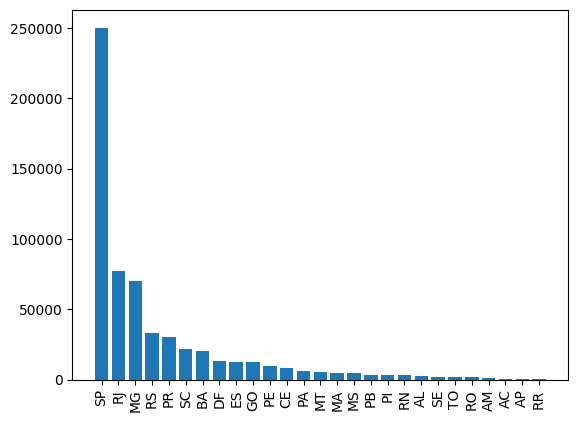

In [27]:
# Count the number of customers from each state. 
query = """SELECT customer_state, COUNT(customer_id) AS customer_count FROM customers 
GROUP BY customer_state;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['State', 'Customer_Count'])
df = df.sort_values(by='Customer_Count', ascending=False)
plt.xticks(rotation=90)
plt.bar(df['State'], df['Customer_Count'])

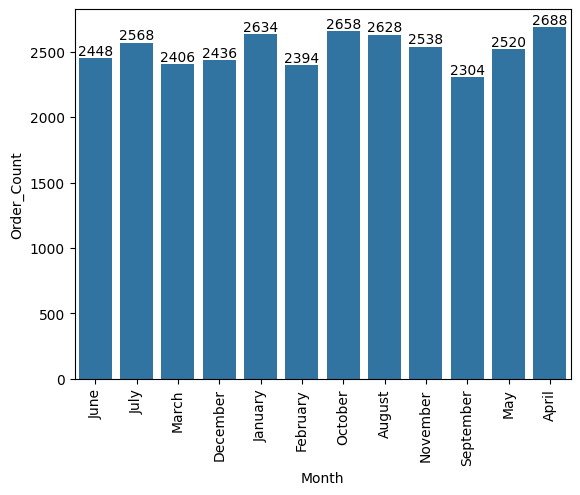

In [41]:
# Calculate the number of orders per month in 2022.
query = """ SELECT MONTHNAME(Order_Date) AS month, COUNT(order_id) AS order_count
            FROM orders WHERE YEAR(Order_Date) = 2022
            GROUP BY month;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Month', 'Order_Count'])
ax = sns.barplot(x='Month', y='Order_Count', data=df)
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0])
plt.show()


In [33]:
cur.execute("SELECT MIN(Order_Date), MAX(Order_Date) FROM orders;")
print(cur.fetchall())

[('2022-01-01', '2023-12-31')]


In [51]:
# Calculate the percentage of total revenue contributed by each product category.
query = """SELECT products.product_category as category, ROUND((SUM(payments.payment_value)/(select sum(payment_value) from payments))*100,2) AS total_sales
            FROM products join order_items ON products.product_id = order_items.product_id
            JOIN payments ON order_items.order_id = payments.order_id
            group by category ORDER BY total_sales DESC; """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Category', 'Percentage_of_Revenue'])
df

,Category,Percentage_of_Revenue
0,bed table bath,42.79
1,HEALTH BEAUTY,41.41
2,computer accessories,39.61
3,Furniture Decoration,35.73
4,Watches present,35.71
...,...,...
69,PC Gamer,0.05
70,House Comfort 2,0.04
71,cds music dvds,0.03
72,Fashion Children's Clothing,0.02


In [56]:
# 4. Identify the correlation between product price and the number of times a product has been purchased.
import numpy as np
query = """SELECT
    p.product_category,
    COUNT(o.product_id) AS product_count,
    ROUND(AVG(o.price), 2) AS average_price
FROM
    products p
JOIN
    order_items o ON p.product_id = o.product_id
GROUP BY
    p.product_category;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Product_Category', 'Purchase_Count', 'Average_Price'])

arr1 = df['Purchase_Count']
arr2 = df['Average_Price']

np.corrcoef(arr1, arr2) 
print("Correlation coefficient between Purchase Count and Average Price:", np.corrcoef(arr1, arr2)[0][1]) 

Correlation coefficient between Purchase Count and Average Price: -0.10631514167157564


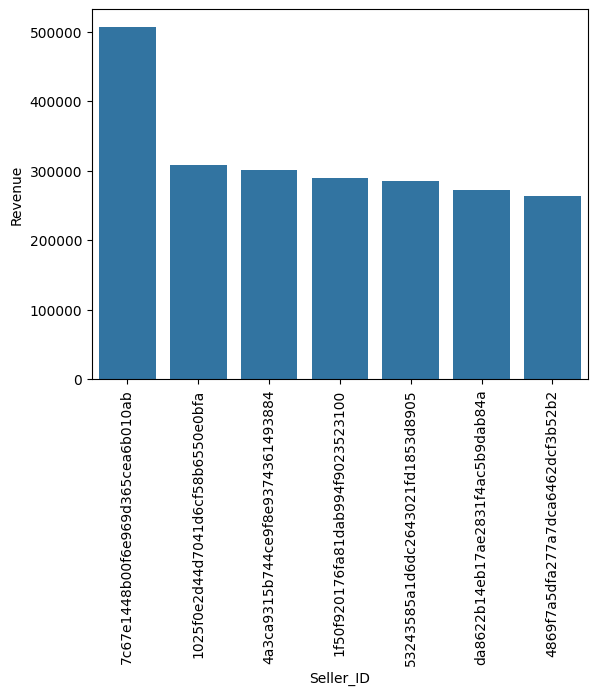

In [60]:
# Calculate the total revenue generated by each seller, and rank them by revenue.
query  = """SELECT *,
       DENSE_RANK() OVER (ORDER BY revenue DESC) AS seller_rank
FROM (
    SELECT 
        order_items.seller_id, 
        SUM(payments.payment_value) AS revenue
    FROM order_items
    JOIN payments 
        ON order_items.order_id = payments.order_id
    GROUP BY order_items.seller_id
) AS a;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Seller_ID', 'Revenue', 'Seller_Rank'])
df = df.head(7)
sns.barplot(x='Seller_ID', y='Revenue', data=df)
plt.xticks(rotation=90)
plt.show()


In [ ]:
# Calculate the cumulative sales per month for each year
query = """SELECT 
    years, 
    months, 
    payment, 
    SUM(payment) OVER (ORDER BY years, months) AS cumulative_sales 
FROM (
    SELECT 
        YEAR(orders.Order_Date) AS years,
        MONTH(orders.Order_Date) AS months,
        ROUND(SUM(payments.payment_value), 2) AS payment 
    FROM orders 
    JOIN payments ON orders.order_id = payments.order_id
    GROUP BY years, months
) AS a
ORDER BY years, months;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Year', 'Month', 'Payment', 'Cumulative_Sales'])
df

,Year,Month,Payment,Cumulative_Sales
0,2022,1,3263399.88,3263399.88
1,2022,2,1131936.54,4395336.42
2,2022,3,3388429.68,7783766.10
3,2022,4,1056377.10,8840143.20
4,2022,5,1244154.96,10084298.16
5,2022,6,3301435.98,13385734.14
6,2022,7,2781965.04,16167699.18
7,2022,8,1160418.30,17328117.48
8,2022,9,470101.92,17798219.40
9,2022,10,1171419.96,18969639.36


In [83]:
# Calculate the year-over-year growth rate of total sales.
query = """with a as(SELECT 
    YEAR(orders.Order_Date) AS years, 
    ROUND(SUM(payments.payment_value), 2) AS payment 
FROM orders 
JOIN payments ON orders.order_id = payments.order_id 
GROUP BY years
ORDER BY years)
select years, (payment - lag(payment,1) over (order by years))/lag(payment,1) over (order by years)*100 as growth_rate, payment as total_sales, lag(payment,1) over (order by years) as previous_year_sales from a;"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Year', 'Growth_Rate', 'Total_Sales', 'Previous_Year_Sales'])
df

,Year,Growth_Rate,Total_Sales,Previous_Year_Sales
0,2022,NaN,23040680.35,NaN
1,2023,-8.324531,21122651.88,23040680.35


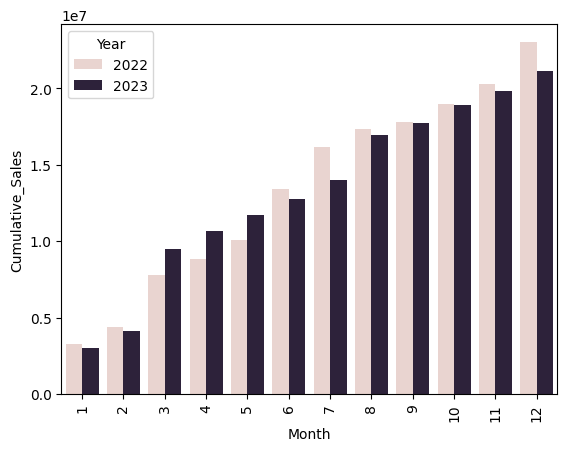

In [ ]:
# Identify the top 3 customers who spent the most money in each year.
query = """
SELECT 
    years, 
    months, 
    payment, 
    SUM(payment) OVER (
        PARTITION BY years 
        ORDER BY months
    ) AS cumulative_sales 
FROM (
    SELECT 
        YEAR(o.Order_Date) AS years,
        MONTH(o.Order_Date) AS months,
        ROUND(SUM(p.payment_value), 2) AS payment 
    FROM orders o
    JOIN payments p 
        ON o.order_id = p.order_id
    GROUP BY 
        YEAR(o.Order_Date), 
        MONTH(o.Order_Date)
) AS a
ORDER BY years, months;
"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['Year', 'Month', 'Payment', 'Cumulative_Sales'])
sns.barplot(x='Month', y='Cumulative_Sales', hue='Year', data=df)
plt.xticks(rotation=90) 
plt.show()